I, Max Wallace, did not use ChatGPT or any other AI/LLM to assist me on this assessment. 

### 2. Read in gourds data, look at top 5 rows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#check out data
gourds = pd.read_csv('./gourds.csv')
gourds.head(5)

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
0,2013,F,154.5 lb,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5
1,2013,F,146.5 lb,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5
2,2013,F,145.0 lb,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0
3,2013,F,140.8 lb,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8
4,2013,F,139.0 lb,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0


### 3. Which country shows up the most frequently in the dataset? Create a visualization (your choice) to show the frequency of appearances for the top 5 countries in terms of number of appearances.

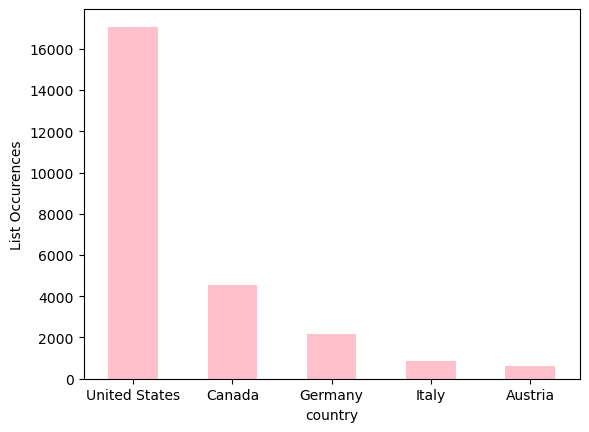

In [2]:
#plot 5 largest country column value counts with pink bars just because
gourds['country'].value_counts().nlargest(5).plot(kind='bar', color='pink')
plt.ylabel("List Occurences")

#change weird 90 degree x axis label rotation to 0 degrees instead of 90
plt.xticks(rotation=0)

plt.show()

### 4. The weight column currently contains a unit ("in" for Long Gourds and "lb" for every other type). Remove the unit from this so that you just have the numeric value and save the result back to the weight column.



In [3]:
#this may requre a 'restart kernel' scenario if this cell acts up.

#replace in and lb with empty strings, strip whitespace, then convert weight values to floats
gourds['weight'] = gourds['weight'].str.replace('in','').str.strip()
gourds['weight'] = gourds['weight'].str.replace('lb','').str.strip()
gourds['weight'] = pd.to_numeric(gourds['weight'])

#make sure the weight column is a float
gourds.info()
gourds.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28011 entries, 0 to 28010
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               28011 non-null  int64  
 1   type_id            28011 non-null  object 
 2   weight             28011 non-null  float64
 3   place              28011 non-null  float64
 4   grower_name        28011 non-null  object 
 5   city               25232 non-null  object 
 6   state_prov         28011 non-null  object 
 7   country            28011 non-null  object 
 8   gpc_site           28011 non-null  object 
 9   seed_mother        19468 non-null  object 
 10  pollinator_father  17704 non-null  object 
 11  ott                24854 non-null  float64
 12  est_weight         24854 non-null  float64
 13  variety            715 non-null    object 
 14  weight_bk          28011 non-null  float64
dtypes: float64(5), int64(1), object(9)
memory usage: 3.2+ MB


,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0


### After doing this, sort the values on the weight column. You should find that the heaviest gourd in the dataset weighs 2702.9 lb. If you cannot find a solution for this question, you can use the weight_bk to answer the questions below that rely on it.



In [4]:
#sort by weight descending; check top 5
gourds.sort_values(by='weight', ascending=False).head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
25730,2021,P,2702.9,1.0,"Cutrupi, Stefano",Radda in Chianti,Tuscany,Italy,Campionato dello Zuccone,1885.5 Werner,Self,514.0,2553.0,NaN,2702.9
9964,2016,P,2624.6,1.0,"Willemijns, Mathias",Deurle,East Flanders,Belgium,Europameisterschaft im Kurbiswiegen,2145 McMullen,1872 Willemijns,496.0,2175.0,NaN,2624.6
22871,2020,P,2593.7,1.0,"Paton, Ian & Stuart",Everton nr. Lymington,England,United Kingdom,Royal Victoria Country Park,"1875 MENDI ""B""",2005 HAIST,502.0,2431.0,NaN,2593.7
22872,2020,P,2551.9,2.0,"Mendi, Ruben",VALTIERRA,Navarre,Spain,Concurso Calabazas Gigantes de Valtierra,2183.7 Mendi 2019,self,485.0,2255.0,NaN,2551.9
16260,2018,P,2528.0,1.0,"Geddes, Steve",Boscawen,New Hampshire,United States,Deerfield Fair,1911 Urena,1803 Gadberry,490.0,2307.0,NaN,2528.0


### 5. Create a line plot showing the trend in the heaviest gourd by year. What do you notice?

#### Weight is trending upward, and 2016 was a standout year for largest gourd. I would hypothesize that this is due to advancements in horticulture.

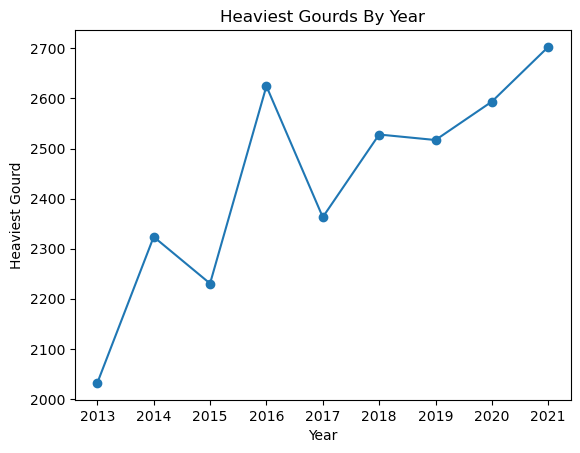

In [5]:
# make dataframe with just weight and year columns, sort by year/weight and drop duplicates in year column
# that way there's just one row per year value
heavy_gourds = (gourds[['weight', 'year']].sort_values(["year", "weight"], ascending=[True, False]).drop_duplicates(subset="year"))

# clearly establish x and y values for my own sanity
x = heavy_gourds['year']
y = heavy_gourds['weight']

plt.plot(x, y, marker='o')
plt.title('Heaviest Gourds By Year')
plt.xlabel('Year')
plt.ylabel('Heaviest Gourd')
plt.show()

### 6. Read the type_name.csv dataset into a new DataFrame named type_name. Merge this with gourds to add on type_name column. Which type of gourd is heaviest on average? Create a visualization showing the distribution of gourd weights by type.

In [6]:
type_name = pd.read_csv('./type_name.csv')

# left join gourds and type_name on the key column 'type_id'
gourds_type = pd.merge(gourds, type_name, how="left", on=["type_id", "type_id"])

# double checking that we have the same amount of rows, A.K.A. did I mess up?
# result.shape
# gourds.shape

In [7]:
# make sure weight is a float
gourds_type['weight'] = pd.to_numeric(gourds_type['weight'])

# new column containing average weight per type_name group. It's like window functions I think.
gourds_type['avg_type_weight'] = gourds_type.groupby('type_name')['weight'].transform('mean')
gourds_type.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,avg_type_weight
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5,Field Pumpkin,79.456309
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5,Field Pumpkin,79.456309
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0,Field Pumpkin,79.456309
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8,Field Pumpkin,79.456309
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0,Field Pumpkin,79.456309


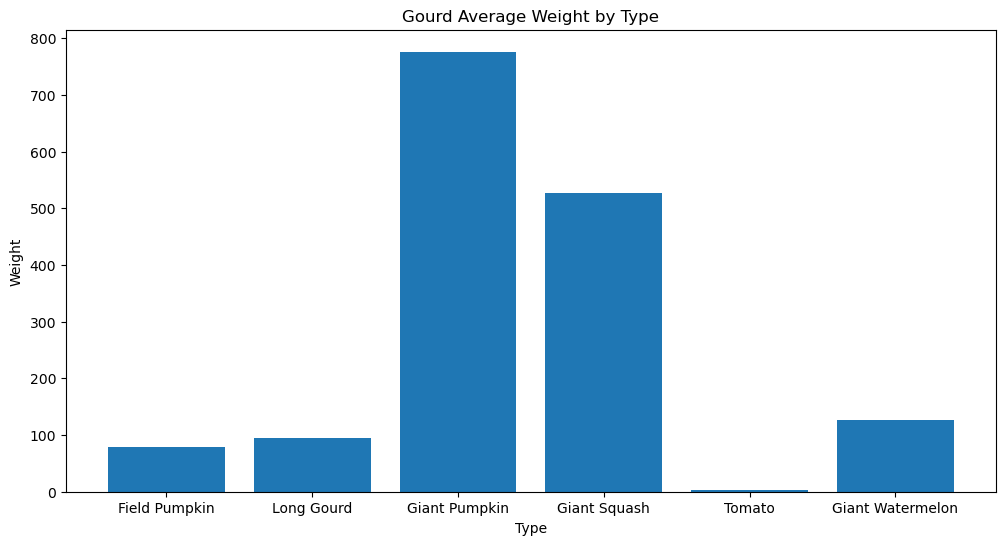

In [8]:
# drop duplicates; was loading really slowly, and we only need a single row per type anyway
gourds_unique = gourds_type.drop_duplicates('type_name')

# plot it
plt.figure(figsize=(12, 6))
plt.bar(gourds_unique['type_name'], gourds_unique['avg_type_weight'])
plt.title('Gourd Average Weight by Type')
plt.xlabel('Type')
plt.ylabel('Weight')
plt.show()

### 7. Create a new column weight_error that contains the amount by which the estimated weight exceeded the actual weight. What is the worst overestimate of a gourd weight? What percentage of gourd weights are overestimated?

In [9]:
#new column with estimated weight subtracted by weight
gourds['weight_error'] = gourds['est_weight'] - gourds['weight']

#sort by weight error descending
gourds[['est_weight', 'weight', 'weight_error']].sort_values(by='weight_error', ascending=False).head()

,est_weight,weight,weight_error
20945,11033.0,316.0,10717.0
13336,9819.0,1419.8,8399.2
12385,1887.0,160.5,1726.5
14910,2369.0,732.0,1637.0
4185,2336.0,803.0,1533.0


In [10]:
# new dataframe with rows where the weight_error column from above is above 0 and sort by weight_error descending
overest_gourds = gourds[gourds['weight_error'] > 0].sort_values(by='weight_error', ascending=False)

# calculate percent overestimated by using the row counts and round to two decimal places (overesstimated gourds/all gourds * 100)
overest_pct = round(overest_gourds.shape[0] / gourds.shape[0] * 100, 2)

print(f'Percentage of Overestimated Gourd Sizes: {overest_pct}%')

Percentage of Overestimated Gourd Sizes: 30.06%


### 8. Create a visualization to compare the estimated weight (est_weight) to the actual weight (weight_lbs). Note that both of these columns are numeric, so choose a type of visualization most appropriate for these data types. What do you notice from your visualization?

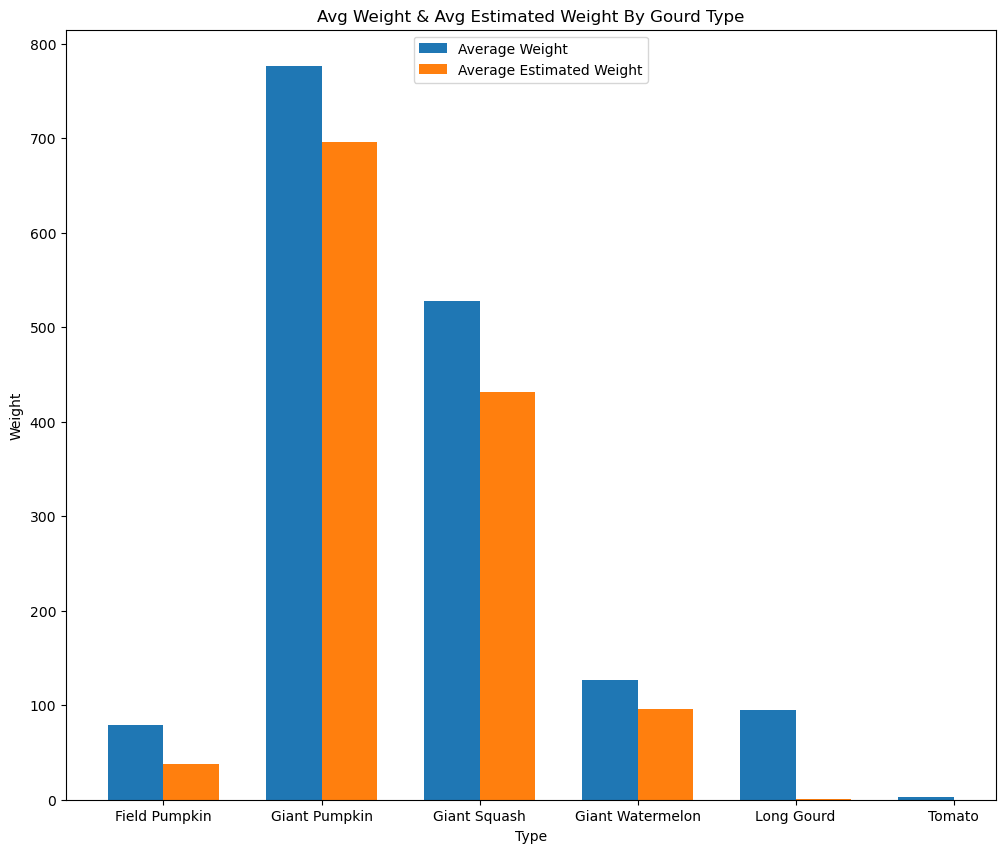

In [11]:
# add column for avg estimated weight to go alongside the column for avg weight
gourds_type['avg_type_est_weight'] = gourds_type.groupby('type_name')['est_weight'].transform('mean')

# new smaller dataframe with just the averages per type because it takes FOREVER if you load 'gourds_types' dataframe
gourds_avgs = gourds_type.groupby('type_name')[['avg_type_weight', 'avg_type_est_weight']].mean().reset_index()

# use the length of type_name column to establish x label position, and choose bar width
x = np.arange(len(gourds_avgs['type_name']))
bar_width = 0.35

# make graph bigger
fig, ax = plt.subplots(figsize=(12, 10))

# shift bars left/right by half their width, and establish bar names for the legend
bars1 = ax.bar(x - bar_width/2, gourds_avgs['avg_type_weight'], bar_width, label='Average Weight')
bars2 = ax.bar(x + bar_width/2, gourds_avgs['avg_type_est_weight'], bar_width, label='Average Estimated Weight')

# graph labels
ax.set_ylabel('Weight')
ax.set_xlabel('Type')
ax.set_title('Avg Weight & Avg Estimated Weight By Gourd Type')
ax.legend()

# set x axis tick positions and label by gourd name
ax.set_xticks(x)
ax.set_xticklabels(gourds_avgs['type_name'])

plt.show()

### 9. Some growers compete across multiple types of gourd. Which grower has top 10 finishes across the largest number of types of gourds? What is this grower's best finish that shows up in the dataset?

In [12]:
# dataframe with only the best, sorted by grower, place, and gourd weight
best_growers = gourds_type[gourds_type['place'] <= 10].sort_values(by=['grower_name','place','weight'], ascending=[True, True, False])

#get unique type_name count per grower_name
variety_count = best_growers.groupby('grower_name')['type_id'].nunique().reset_index()

#rename type_id column so it makes sense
variety_count.rename(columns={'type_id': 'grower_type_count'}, inplace=True)

#get the maximum value in grower_type_count and match with grower(s) to the most_types value
most_types = variety_count['grower_type_count'].max()
best_variety_growers = variety_count[variety_count['grower_type_count'] == most_types]

print(best_variety_growers)


                 grower_name  grower_type_count
130  Martin, Margaret & Glen                  4


In [13]:
# show rows where grower name matches grower from the previous cell, sort rows by place ascending(#1 at the top), then just show the top result
gourds[gourds['grower_name'] == 'Martin, Margaret & Glen'].sort_values(by='place', ascending=True).head(1)

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,weight_error
5496,2014,T,7.45,2.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,5.63 Martin uof '13 (big zac),open,NaN,NaN,Big Zac,7.45,NaN


### 10. The seed_mother and pollinator_father give information on the parents for each gourd.

### a. How many gourds appear in the seed_mother column at least 100 times?

#### 2 that we know of: 2145 McMullen & 2009 Wallace 

In [14]:
mother_counts = gourds['seed_mother'].value_counts()
frequent_mothers = mother_counts[mother_counts >= 100]
frequent_mothers

seed_mother
unknown          277
Unknown          260
2145 McMullen    122
2009 Wallace     104
Name: count, dtype: int64

### b. How many gourds appear in the pollinator_father column at least 100 times?

#### 2 that we know of: 2145 McMullen & 2009 Wallace 

In [15]:
father_counts = gourds['pollinator_father'].value_counts()
frequent_fathers = father_counts[father_counts >= 100]
frequent_fathers

pollinator_father
open             2658
Open             2065
self             2020
Self             1875
2009 Wallace      146
2145 McMullen     125
unknown           114
Unknown           100
Name: count, dtype: int64

### c. How many gourds have at least 100 offspring that have appeared in the GPC Weighoff? That is, how many gourds appear at least 100 times between the seed_mother and pollinator_father columns combined? Hint: One way you could do this is to create two value_counts Series on the seed_mother and pollinator_father columns and merge them.

#### 5 that we know of

In [16]:
# combine mother_counts and father_counts
# use the add method with fill_value=0 to make sure the addition doesn't come across NaN values
parent_counts = father_counts.add(mother_counts, fill_value=0)

# only parents with 100+ offspring in the gpc weighoff please and thank you
frequent_parents = parent_counts[parent_counts >= 100]
frequent_parents

1911 Urena        135.0
1985 Miller       158.0
2009 Wallace      250.0
2145 McMullen     247.0
2363 Holland      118.0
Open             2092.0
Self             1876.0
Unknown           360.0
open             2685.0
self             2022.0
unknown           391.0
Name: count, dtype: float64